
Predictions:
Actual: setosa | Predicted: setosa
Actual: setosa | Predicted: setosa
Actual: setosa | Predicted: setosa
Actual: setosa | Predicted: setosa
Actual: setosa | Predicted: setosa
Actual: setosa | Predicted: setosa
Actual: setosa | Predicted: setosa
Actual: setosa | Predicted: setosa
Actual: setosa | Predicted: setosa
Actual: setosa | Predicted: setosa
Actual: setosa | Predicted: setosa
Actual: setosa | Predicted: setosa
Actual: setosa | Predicted: setosa
Actual: setosa | Predicted: setosa
Actual: setosa | Predicted: setosa
Actual: setosa | Predicted: setosa
Actual: setosa | Predicted: setosa
Actual: setosa | Predicted: setosa
Actual: setosa | Predicted: setosa
Actual: setosa | Predicted: setosa
Actual: setosa | Predicted: setosa
Actual: setosa | Predicted: setosa
Actual: setosa | Predicted: setosa
Actual: setosa | Predicted: setosa
Actual: setosa | Predicted: setosa
Actual: setosa | Predicted: setosa
Actual: setosa | Predicted: setosa
Actual: setosa | Predicted: setosa
Actual

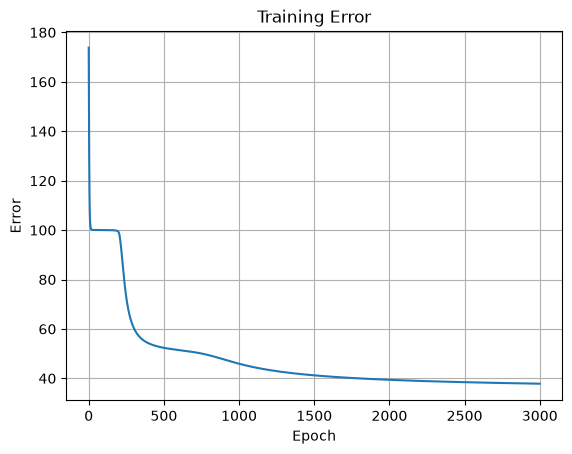

In [5]:
# Neural Network with Backpropagation
# Iris Dataset
# Architecture: 4 -> 2 -> 3
from sklearn import datasets
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
iris = datasets.load_iris()

X = iris.data
y = iris.target


# One-hot encoding
Y = np.zeros((150, 3))

for i in range(150):
    Y[i][y[i]] = 1


# Activation function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


# Derivative
def dsigmoid(x):
    return x * (1 - x)


# Weights
w1 = np.random.rand(4, 2)
w2 = np.random.rand(2, 3)

lr = 0.01
ep = 3000

err_list = []


# Training
for e in range(ep):

    err_sum = 0

    for i in range(len(X)):

        # Forward propagation

        h = sigmoid(np.dot(X[i], w1))

        o = sigmoid(np.dot(h, w2))


        # Error

        err = o - Y[i]

        err_sum += np.sum(err ** 2)


        # Backpropagation

        d2 = err * dsigmoid(o)

        d1 = np.dot(w2, d2) * dsigmoid(h)


        # Update weights

        w2 = w2 - lr * np.outer(h, d2)

        w1 = w1 - lr * np.outer(X[i], d1)

    err_list.append(err_sum)


# Prediction

print("\nPredictions:")

correct = 0

for i in range(len(X)):

    h = sigmoid(np.dot(X[i], w1))

    o = sigmoid(np.dot(h, w2))

    pred = np.argmax(o)

    if pred == y[i]:
        correct += 1

    print(
        "Actual:", iris.target_names[y[i]],
        "| Predicted:", iris.target_names[pred]
    )


# Accuracy
acc = (correct / len(X)) * 100

print("\nAccuracy:", acc, "%")


# Final weights
print("\nFinal w1:")
print(w1)

print("\nFinal w2:")
print(w2)


# Error graph
plt.plot(err_list)

plt.xlabel("Epoch")
plt.ylabel("Error")
plt.title("Training Error")

plt.grid()
plt.show()